In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define datasets and methods
datasets = ['mnist', 'fmnist', 'cifar10', 'svhn']
methods = ['custom', 'random', 'oort']

# Define filenames
files = {
    'mnist': {
        'custom': 'output_mnist_custom_global_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
        'random': 'output_mnist_random_global_dirichlet_Q8_lr0.01_ep1_w0.4_NEW.txt',
        'oort': 'output_mnist_oort_global_dirichlet_NEW.txt',
    },
    'fmnist': {
        'custom': 'output_fmnist_custom_global_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
        'random': 'output_fmnist_random_global_dirichlet_Q8_lr0.01_ep1_w0.4_NEW.txt',
        'oort': 'output_fmnist_oort_global_dirichlet_NEW.txt',
    },
    'cifar10': {
        'custom': 'output_cifar10_custom_global_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
        'random': 'output_cifar10_random_global_dirichlet_Q8_lr0.01_ep1_w0.4_NEW.txt',
        'oort': 'output_cifar10_oort_global_dirichlet_NEW.txt',
    },
    'svhn': {
        'custom': 'output_svhn_custom_global_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
        'random': 'output_svhn_random_global_dirichlet_lr0.01_ep1.txt',
        'oort': 'output_svhn_oort_global_dirichlet_NEW.txt',
    }
}

base_dir = "/home/kamrul/Documents/kamrul_files_Linux/OORT/ClusterFed_OORT/results/svhn2/"

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Define datasets and methods
# datasets = ['mnist', 'fmnist', 'cifar10', 'svhn']
# methods = ['custom', 'random', 'oort']

# # Define filenames
# files = {
#     'mnist': {
#         'custom': 'output_mnist_custom_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'random': 'output_mnist_random_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'oort': 'output_mnist_oort_local_dirichlet.txt',
#     },
#     'fmnist': {
#         'custom': 'output_fmnist_custom_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'random': 'output_fmnist_random_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'oort': 'output_fmnist_oort_local_dirichlet.txt',
#     },
#     'cifar10': {
#         'custom': 'output_cifar10_custom_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'random': 'output_cifar10_random_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'oort': 'output_cifar10_oort_local_dirichlet.txt',
#     },
#     'svhn': {
#         #'custom': 'output_svhn_custom_local_dirichlet_Q8_lr0.01_ep1_w0.4.txt',
#         'custom': 'output_svhn_custom_local_dirichlet_Q8_lr0.01_ep1_w0.5_NEW_NEW.txt',
#         'random': 'output_svhn_random_local_dirichlet_Q8_lr0.01_ep1.txt',
#         'oort': 'output_svhn_oort_local_dirichlet_NEW.txt',
#     }
# }

# base_dir = "/home/kamrul/Documents/kamrul_files_Linux/OORT/ClusterFed_OORT/results/svhn2/"

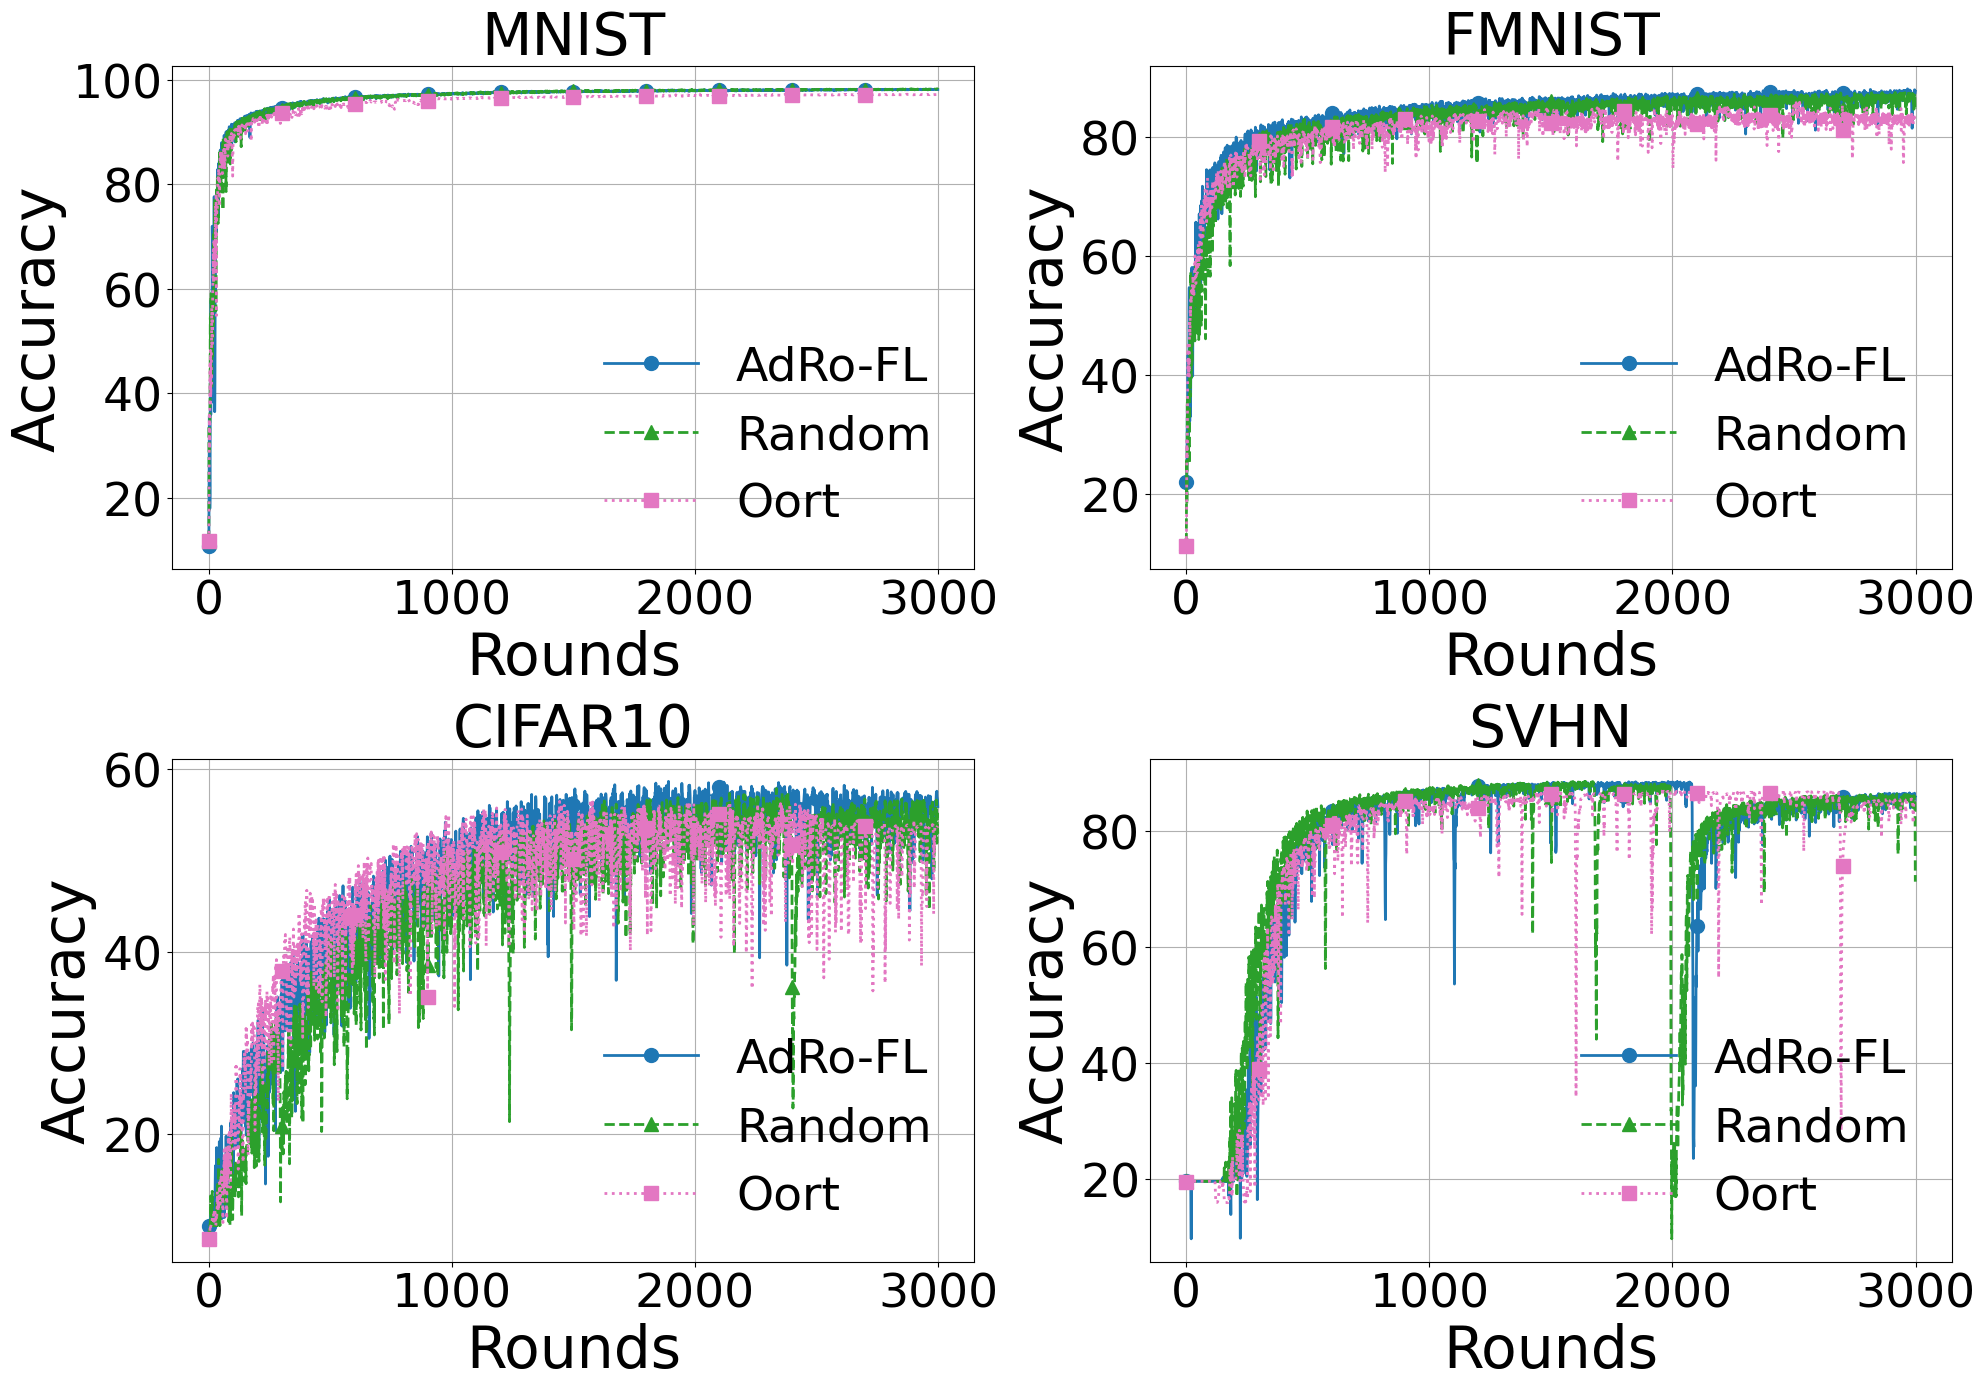

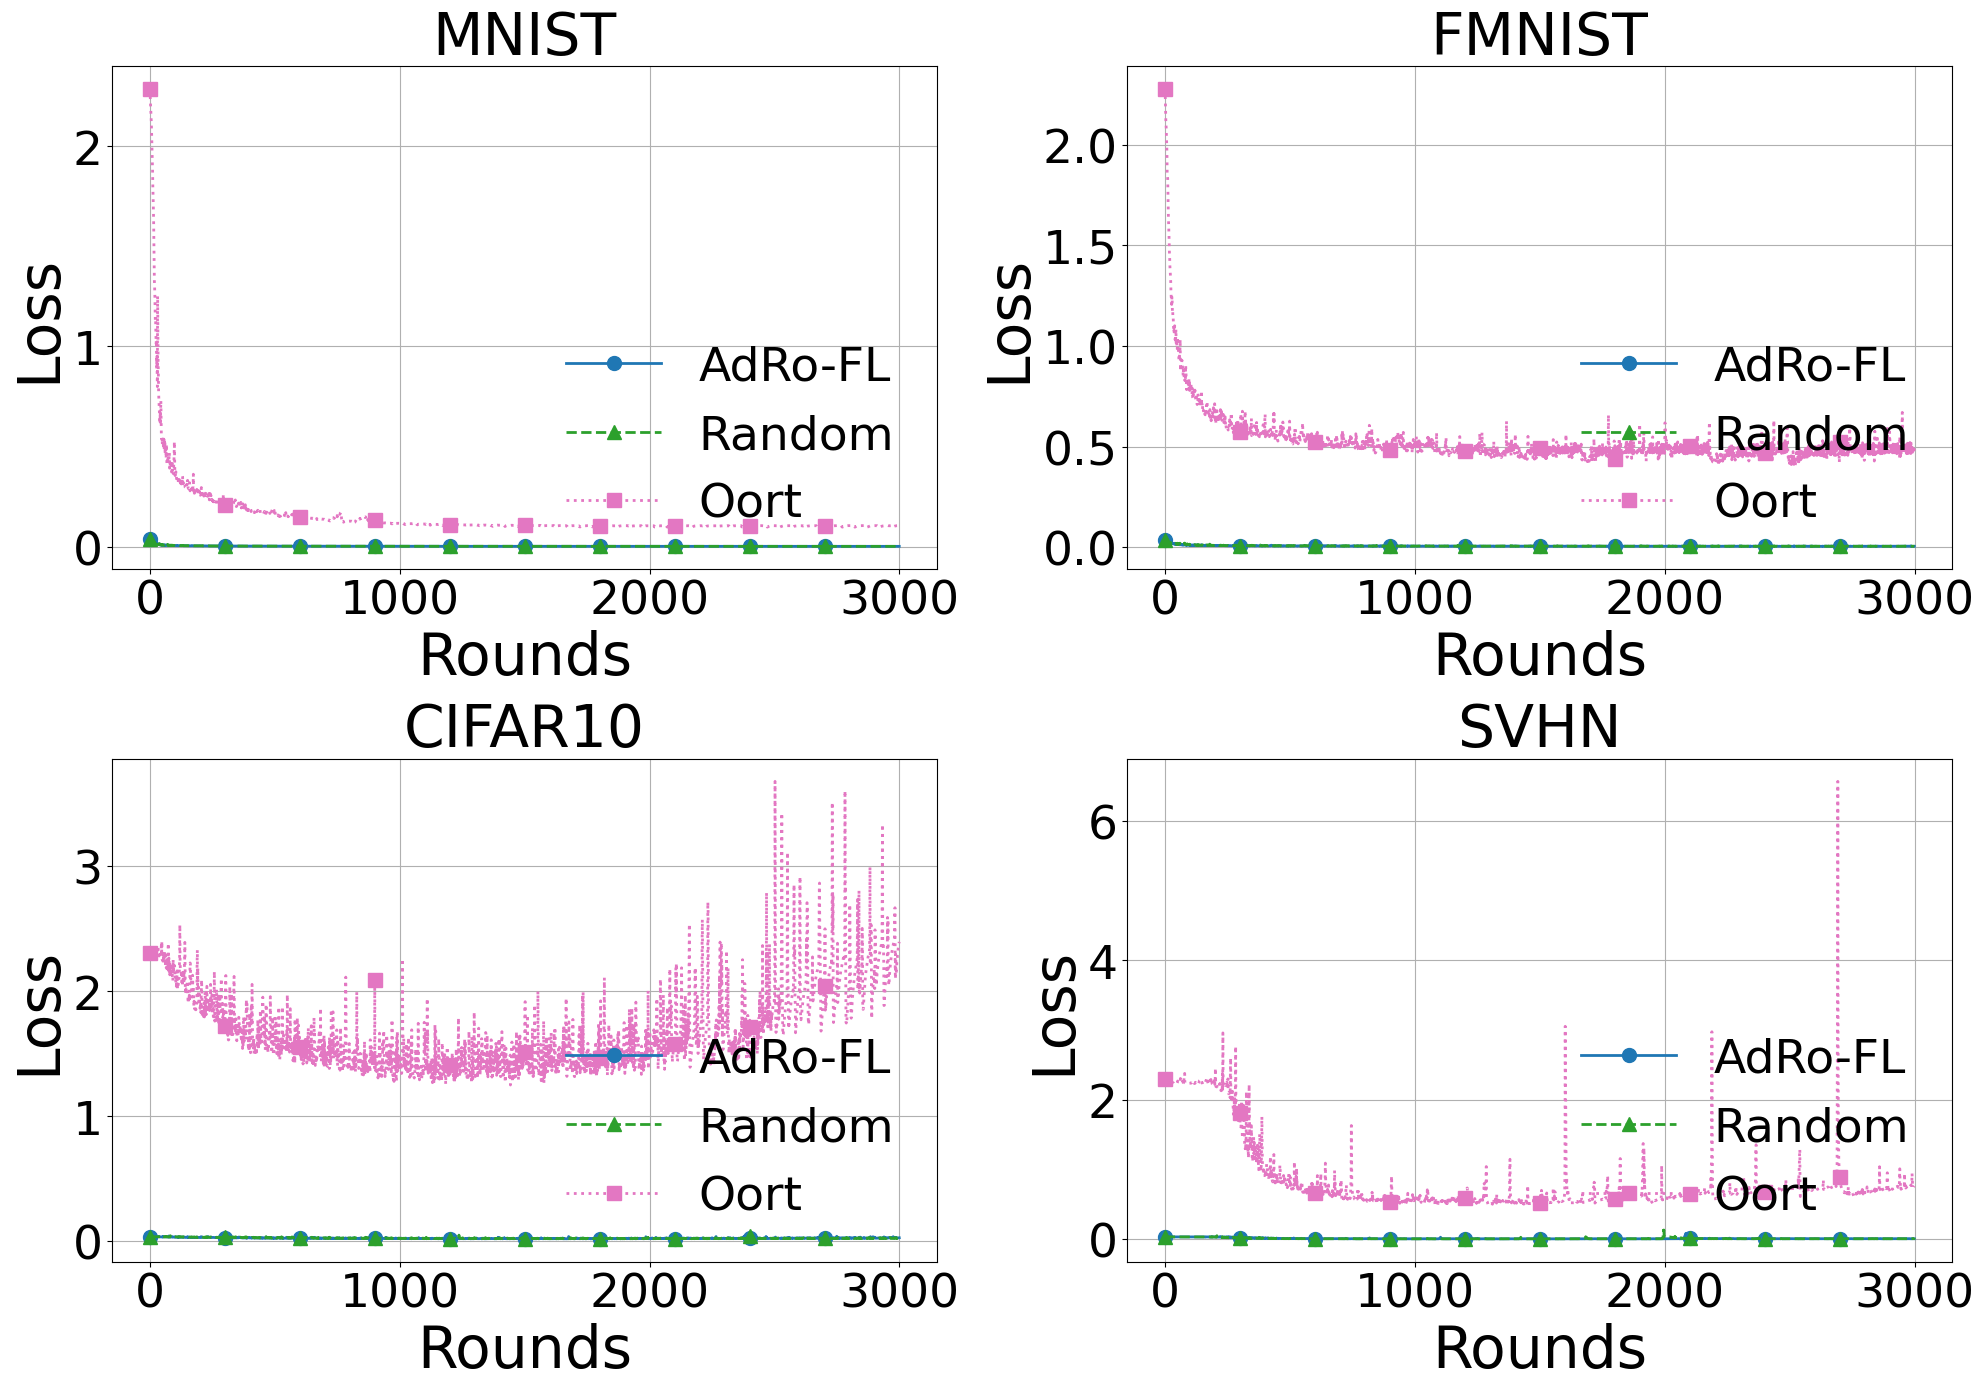

In [11]:
# Function to load metrics from files
def load_metric(file_name, key):
    data = {}
    with open(base_dir + file_name, "r") as f:
        for line in f:
            parts = line.strip().split("=", 1)
            if len(parts) == 2:
                var_name = parts[0].strip()
                try:
                    data[var_name] = eval(parts[1].strip())
                except Exception as e:
                    print(f"Error parsing {var_name} in {file_name}: {e}")
    return data.get(key, [])

# Common font sizes
label_fontsize = 42
legend_fontsize = 34
tick_fontsize = 34

# Colors and styles
colors = {'custom': 'tab:blue', 'random': 'tab:green', 'oort': 'tab:pink'}
linestyles = {'custom': '-', 'random': '--', 'oort': ':'}
markers = {'custom': 'o', 'random': '^', 'oort': 's'}

# Plotting function
def plot_metric(metric_name, ylabel):
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()

    for idx, dataset in enumerate(datasets):
        ax = axes[idx]

        min_rounds = float('inf')
        metrics = {}

        for method in methods:
            metric_data = load_metric(files[dataset][method], f"{metric_name}_{method}")
            metrics[method] = metric_data
            min_rounds = min(min_rounds, len(metric_data))

        rounds = np.arange(min_rounds)

        for method in methods:
            ax.plot(
                rounds, metrics[method][:min_rounds],
                label='AdRo-FL' if method == 'custom' else method.capitalize(),
                color=colors[method],
                linestyle=linestyles[method],
                marker=markers[method],
                markevery=max(1, min_rounds // 10),
                markersize=10,
                linewidth=2
            )

        ax.set_title(dataset.upper(), fontsize=label_fontsize)
        ax.set_xlabel("Rounds", fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        ax.grid(True)

    # Individual legends inside each subplot
    for ax in axes:
        ax.legend(loc='lower right', fontsize=legend_fontsize, frameon=False, fancybox=True, shadow=True)

    fig.tight_layout()
    plt.show()

# Plot Accuracy
plot_metric("accuracy", "Accuracy")

# Plot Loss
plot_metric("loss", "Loss")
